# Lecture 14: Clustering class demo

![](../../img/eva-fun-times.png)

## Let's cluster images!!

For this demo, I'm going to use two image datasets: 
1. A small subset of [200 Bird Species with 11,788 Images](https://www.kaggle.com/datasets/veeralakrishna/200-bird-species-with-11788-images) dataset (available [here](../data/birds.zip))
2. A tiny subset of [Food-101](https://www.kaggle.com/datasets/kmader/food41?select=food_c101_n10099_r32x32x1.h5)
(available [here](../data/food.zip))


To run the code below, you need to install pytorch and torchvision in the course conda environment. 

```conda install pytorch torchvision -c pytorch```

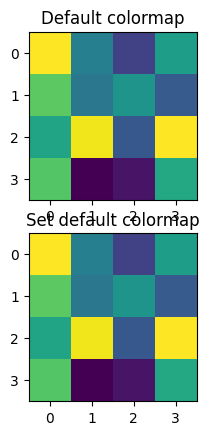

In [1]:
import os
import random
import sys
import time

import numpy as np
import pandas as pd

sys.path.append(os.path.join("code"))
from plotting_functions_unsup import *

import torch
import torchvision
from torchvision import datasets, models, transforms, utils
from PIL import Image
import matplotlib.pyplot as plt
import random

Let's start with  small subset of birds dataset. You can experiment with a bigger dataset if you like.

In [2]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
device

device(type='mps')

In [3]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

In [4]:
set_seed(seed=42)

In [5]:
import glob
IMAGE_SIZE = 224
def read_img_dataset(data_dir):     
    data_transforms = transforms.Compose(
        [
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),     
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),            
        ])
               
    image_dataset = datasets.ImageFolder(root=data_dir, transform=data_transforms)
    dataloader = torch.utils.data.DataLoader(
         image_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
    )
    dataset_size = len(image_dataset)
    class_names = image_dataset.classes
    inputs, classes = next(iter(dataloader))
    return inputs, classes

In [6]:
def plot_sample_imgs(inputs):
    plt.figure(figsize=(10, 70)); plt.axis("off"); plt.title("Sample Training Images")
    plt.imshow(np.transpose(utils.make_grid(inputs, padding=1, normalize=True),(1, 2, 0)));

In [7]:
data_dir = "data/birds"
file_names = [image_file for image_file in glob.glob(data_dir + "/*/*.jpg")]
n_images = len(file_names)
BATCH_SIZE = n_images  # because our dataset is quite small
birds_inputs, birds_classes = read_img_dataset(data_dir)

In [8]:
X_birds = birds_inputs.numpy()

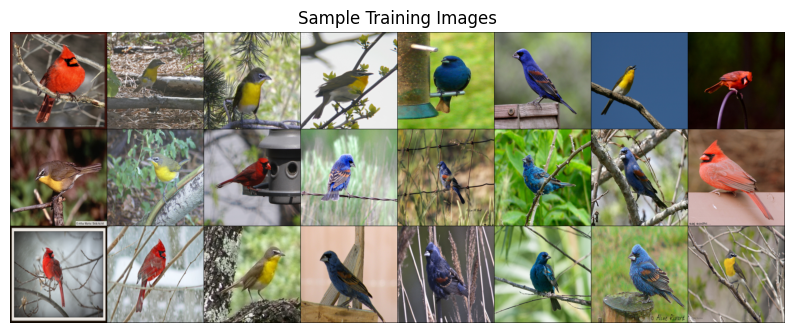

In [9]:
plot_sample_imgs(birds_inputs[0:24,:,:,:])
plt.show()

For clustering we need to calculate distances between points. So we need a vector representation for each data point. A simplest way to create a vector representation of an image is by flattening the image.  

In [10]:
flatten_transforms = transforms.Compose([    
                    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
                    transforms.ToTensor(),
                    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),    
                    transforms.Lambda(torch.flatten)])
flatten_images = datasets.ImageFolder(root='data/birds', transform=flatten_transforms)

In [11]:
flatten_dataloader = torch.utils.data.DataLoader(
        flatten_images, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
    )

In [12]:
flatten_train, y_train = next(iter(flatten_dataloader))

In [13]:
flatten_images = flatten_train.numpy()

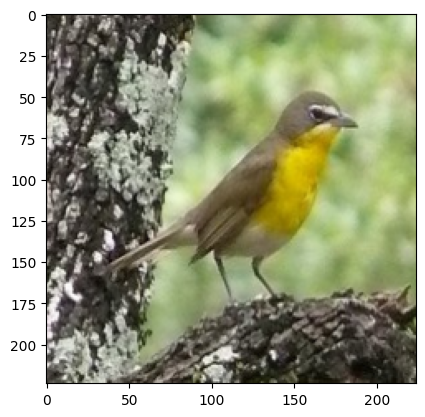

In [14]:
image_shape=[3,224,224]
img = flatten_images[20].reshape(image_shape)
plt.imshow(np.transpose(img / 2 + 0.5, (1, 2, 0)));

In [15]:
flatten_images.shape # 224 by 224 images with 3 color channels

(176, 150528)

In [16]:
from sklearn.cluster import KMeans
k = 3
km_flatten = KMeans(k, n_init='auto', random_state=123)
km_flatten.fit(flatten_images)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",123
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [17]:
km_flatten.cluster_centers_.shape

(3, 150528)

In [18]:
flatten_images.shape

(176, 150528)

In [19]:
unflatten_inputs = np.array([img.reshape(image_shape) for img in flatten_images])

158
Image indices:  [158  65  48 125  95]


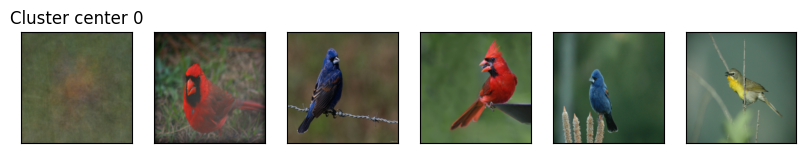

165
Image indices:  [165  94  77 152 108]


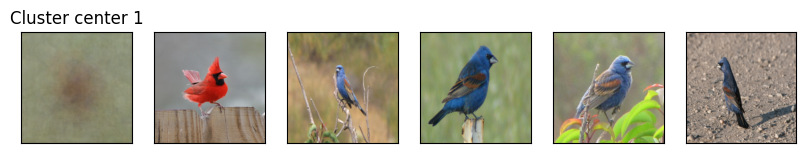

156
Image indices:  [156  89 100  25 133]


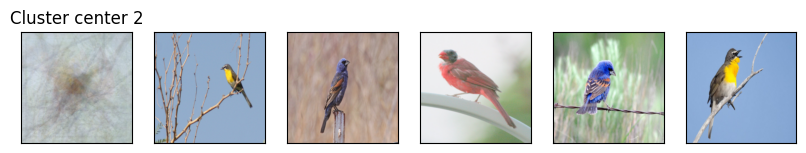

In [20]:
for cluster in range(k):
    # user-defined functions defined in ../code/plotting_functions.py
    get_cluster_images(km_flatten, flatten_images, unflatten_inputs, cluster, n_img=5)

We still see some mis-categorizations. It seems like when we flatten images, clustering doesn't seem that great.  

How about trying out a different input representation? Let's use transfer learning as a feature extractor with a pre-trained vision model. For each image in our dataset we'll pass it through a pretrained network and get a representation from the last layer, before the classification layer given by the pre-trained network. 

![](img/cnn-ex.png)

Source: https://cezannec.github.io/Convolutional_Neural_Networks/

In [26]:
def get_features(model, inputs):
    """Extract output of densenet model"""
    model.eval()
    with torch.no_grad():  # turn off computational graph stuff        
        Z = model(inputs).detach().numpy()         
    return Z

In [27]:
densenet = models.densenet121(weights="DenseNet121_Weights.IMAGENET1K_V1")
densenet.classifier = torch.nn.Identity()  # remove that last "classification" layer
Z_birds = get_features(densenet, birds_inputs)

In [28]:
Z_birds.shape

(176, 1024)

Do we get better clustering with this representation? 

In [29]:
from sklearn.cluster import KMeans

k = 3
km = KMeans(n_clusters=k, n_init='auto', random_state=123)
km.fit(Z_birds)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",123
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [30]:
km.cluster_centers_.shape

(3, 1024)

103
Image indices:  [103  23  86 162 168 122]


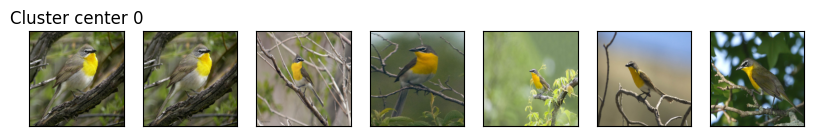

55
Image indices:  [55 31 53 15 88 84]


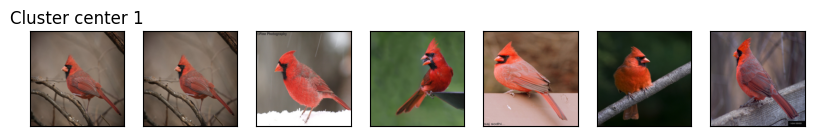

120
Image indices:  [120   5  11  14  22  69]


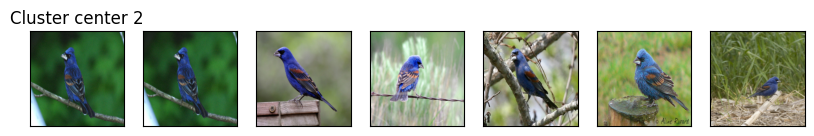

In [31]:
for cluster in range(k):
    # user-defined functions defined in ../code/plotting_functions.py
    get_cluster_images(km, Z_birds, X_birds, cluster, n_img=6)

Cool! KMeans seems to be doing a good job with this representation. 

This dataset seems easier, as the birds have very distinct colors. Let's try a bit more complicated dataset.  

In [37]:
data_dir = "data/food"
file_names = [image_file for image_file in glob.glob(data_dir + "/*/*.jpg")]
n_images = len(file_names)
BATCH_SIZE = n_images  # because our dataset is quite small
food_inputs, food_classes = read_img_dataset(data_dir)
n_images

FileNotFoundError: Found no valid file for the classes .ipynb_checkpoints. Supported extensions are: .jpg, .jpeg, .png, .ppm, .bmp, .pgm, .tif, .tiff, .webp

In [ ]:
X_food = food_inputs.numpy()

In [ ]:
plot_sample_imgs(food_inputs[0:24,:,:,:])

In [ ]:
Z_food = get_features(
    densenet, food_inputs, 
)

In [ ]:
Z_food.shape

In [ ]:
from sklearn.cluster import KMeans

k = 5
km = KMeans(n_clusters=k, n_init='auto', random_state=123)
km.fit(Z_food)

In [ ]:
km.cluster_centers_.shape

In [ ]:
for cluster in range(k):
    get_cluster_images(km, Z_food, X_food, cluster, n_img=6)

There are some mis-classifications but overall it seems pretty good! You can experiment with 
- Different values for number of clusters
- Different pre-trained models
- Other possible representations 
- Different image datasets